In [ ]:
# 1강 2장 1-1
import pandas as pd

# 2. dataset.csv 데이터프레임 저장
df = pd.read_csv("dataset.csv")

# 3. info()함수로 데이터 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [ ]:
# 3. 데이터 결측치 개수 확인
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [ ]:
# 4. artist와 track_name 결측치 최빈값으로 대체
mode_artist = df['artists'].mode()[0]
df.loc[:, 'artists'] = df['artists'].fillna(mode_artist)

mode_track_name = df['track_name'].mode()[0]
df.loc[:, 'track_name'] = df['track_name'].fillna(mode_track_name)

df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          1
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [ ]:
# 5. tempo와 populaity 상태 확인
df.loc[:10, ['tempo', 'popularity']]

,tempo,popularity
0,87.917,73
1,77.489,55
2,76.332,57
3,181.740,71
4,119.949,82
5,98.017,58
6,141.284,74
7,150.960,80
8,130.088,74
9,78.899,56


In [ ]:
# a. 그외의 결측치 대체
mode_album_name = df['album_name'].mode()[0]
df.loc[:, 'album_name'] = df['album_name'].fillna(mode_album_name)

In [ ]:
# 결과. 최종 결측치 처리 유무 확인
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [33]:
# 1강 2장 2-1
duplicate_count = df.duplicated().sum()
print(f"중복된 데이터 개수: {duplicate_count}개")

중복된 데이터 개수: 0개


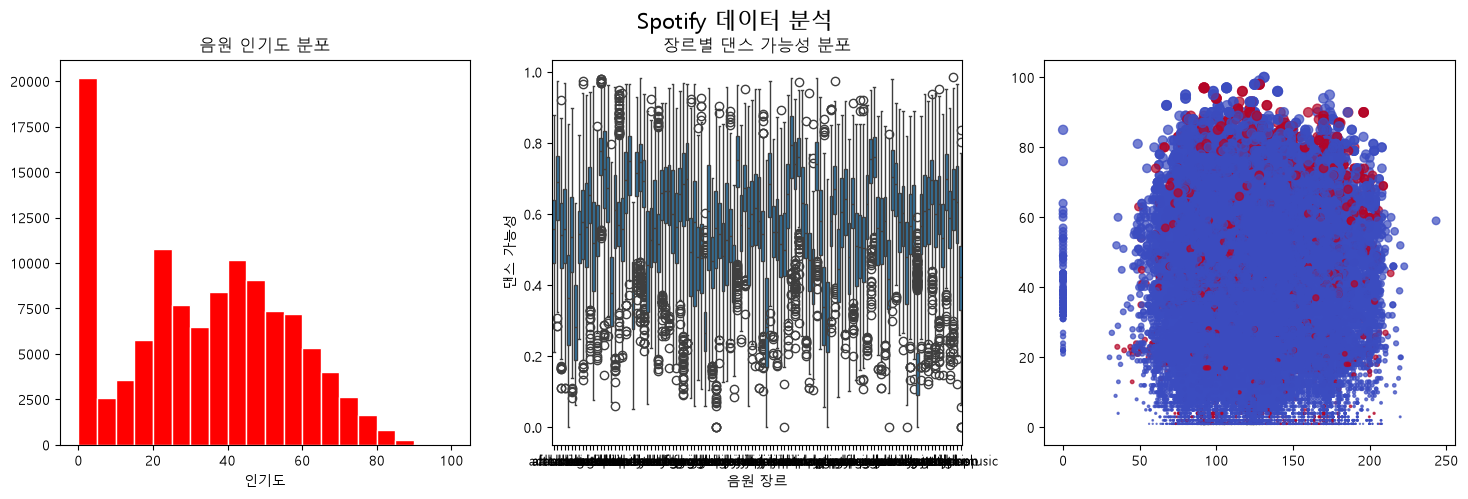

In [47]:
# 1강 2장 3-1
# 1. 필요 라이브러리 임포트
import matplotlib.pyplot as plt
import platform
from matplotlib import rc
import seaborn as sns

# 1. os에 따른 한글 폰트 텍스트 깨짐 방지
os_name = platform.system()

if os_name == "Windows":
    rc("font", family="Malgun Gothic")
else:
    rc("font", family="AppleGothic")

# 2. 1행 3열 그래프 생성
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('Spotify 데이터 분석', fontsize=16)

# 3. [히스토그램] 음원 인기도
axes[0].hist(df['popularity'], bins=20, color='red', edgecolor='white')
axes[0].set_title("음원 인기도 분포")
axes[0].set_xlabel('인기도')
axes[0].set_ylabel('')

# 4. [박스 플롯] 장르별 댄스 가능성
sns.boxplot(x='track_genre', y='danceability', data=df, ax=axes[1])
axes[1].set_title('장르별 댄스 가능성 분포')
axes[1].set_xlabel('음원 장르')
axes[1].set_ylabel('댄스 가능성')

# 5. [산점도] 템포 인기도
scatter = axes[2].scatter(
    df['tempo'], 
    df['popularity'], 
    c=df['explicit'],       # 생존 여부(1: 생존, 0: 사망)
    cmap='coolwarm',        # 1 : 빨강, 0 : 파랑
    s=df['popularity'] / 2,       # 원 사이즈 설정 (50%)
    alpha=0.7
)
